In [2]:
import rasterio
import os
import subprocess
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from importlib import reload
import utils
reload(utils)


<module 'utils' from '/n/home10/erolf/tree_mapping/process_data/../utils.py'>

In [3]:
DATA_DIR = '../data'

### This Notebook processes data layers to align to the coarsest resolution of data available.
1. The first step is to aggregate the individuals tifs into one tif per site (if you don't already have that file)
2. The second step coarsens data to the resolution of a target image tif.
   - aggregation takes the average value of cells that are not nodata

## 1. merge lidar data by site 
By running `python merge_lidar_by_site.py`
The following code plots the results.

We have lidar data at 1m resolution for 15 sites


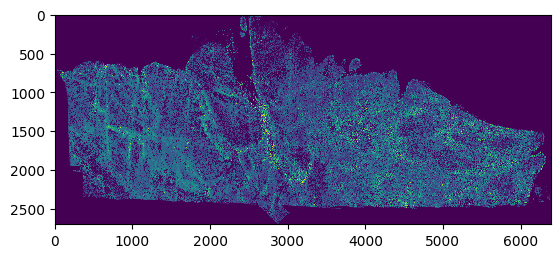

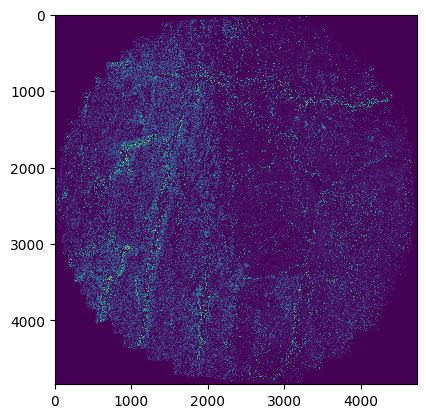

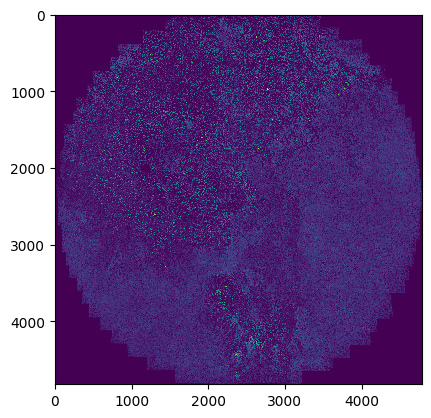

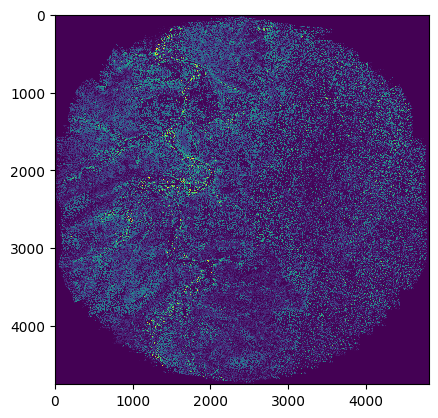

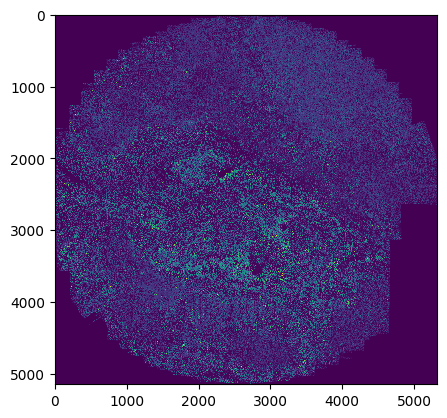

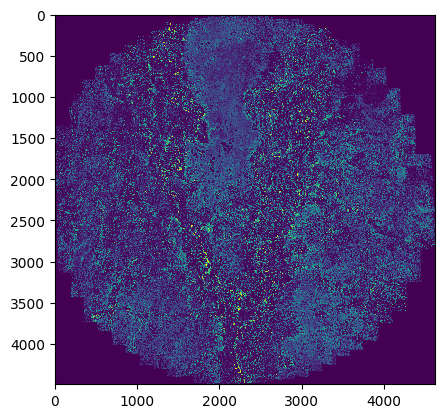

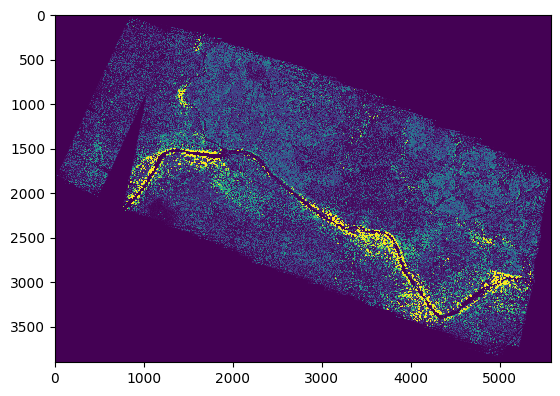

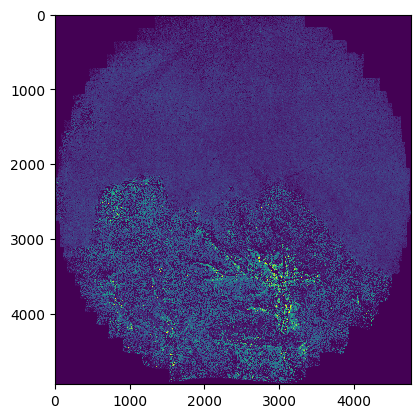

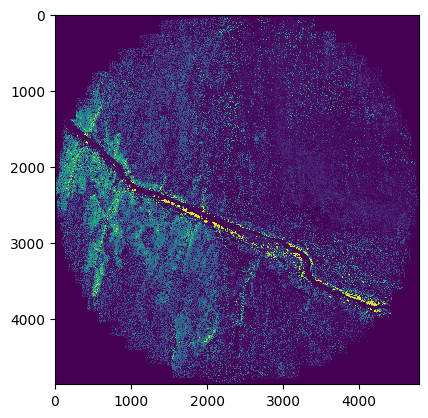

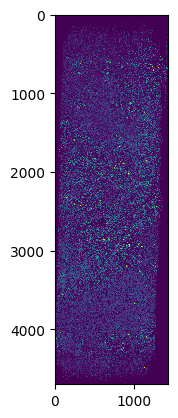

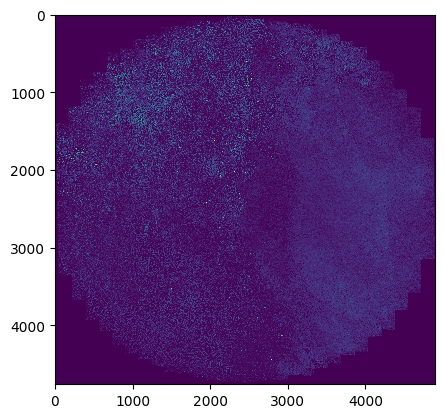

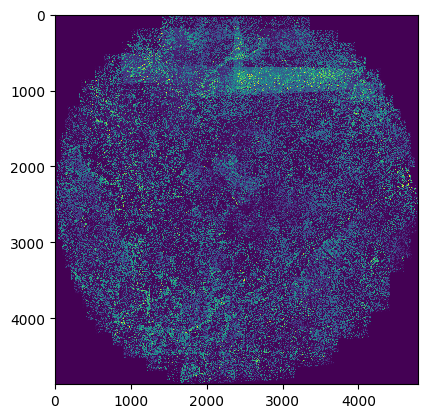

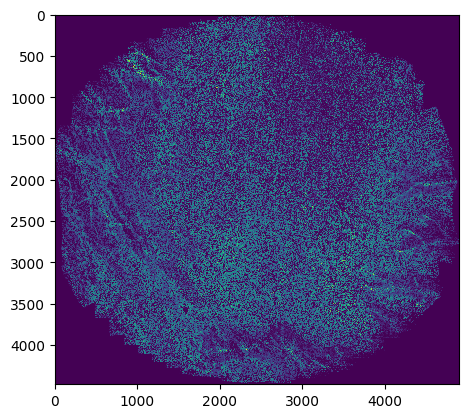

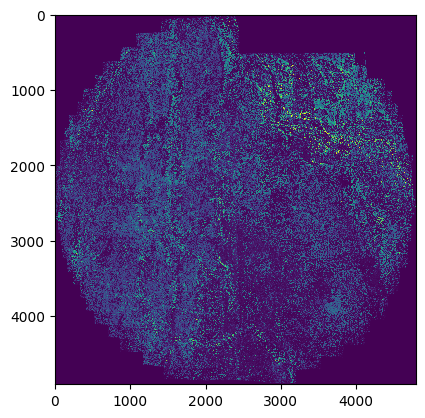

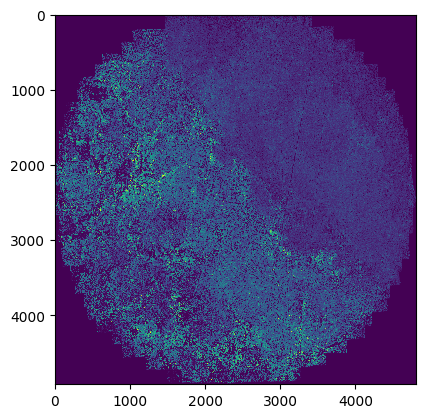

In [22]:
merged_lidar_dir_1m = os.path.join(DATA_DIR, 'raw','lidar_by_site_32736')
processed_tif_fns = os.listdir(merged_lidar_dir_1m)
processed_tif_fps = [os.path.join(merged_lidar_dir_1m, x) for x in processed_tif_fns]
print(f'We have lidar data at 1m resolution for {len(processed_tif_fps)} sites') 

plot_raw_lidar = True
if plot_raw_lidar:
    for processed_site_tif in processed_tif_fps:
        fig, ax = plt.subplots()
        with rasterio.open(processed_site_tif) as f:
            d = f.read()

        plt.imshow(d[0], vmin=0, vmax=15, interpolation='none')

## 2.coarsen data 
### 2.a. lidar data to 10m resolution



## step 2 - coarsen chm data to the resolution of the imagery



In [5]:
if not os.path.exists(f'{data_dir}/lidar/Karingani_merged_crs_10'):
    os.mkdir(f'{data_dir}/lidar/Karingani_merged_crs_10')
    print('made dir ',f'{data_dir}/lidar/Karingani_merged_crs_10')

In [218]:
def coarsen_lidar(input_fn,
                  output_fn,
                  target_fn):

    # aggregate to the resolution of the target_fn
    TMP_FN = '../data/tmp/tmp.tif'
    
    with rasterio.open(target_fn, "r") as f:
        left, bottom, right, top = f.bounds
        crs = f.crs.to_string()
        height, width = f.height, f.width
        res_x, res_y = f.res
    print(crs)
    command = [
        "gdalwarp",
        "-overwrite",
        "-ot", "Float32",
        "-t_srs", crs,
        "-r", "average",  # this is the important bit
        "-of", "GTiff",
     #   "-te", str(left), str(bottom), str(right), str(top),
      #  "-ts", str(width), str(height),
        "-tr", str(res_x), str(res_y),
        "-co", "COMPRESS=LZW",
      #  "-co", "BIGTIFF=YES",
        "-srcnodata", "-9999.",
        "-dstnodata", "-9999.",
        input_fn,
        output_fn
    ]
    subprocess.call(command)


In [220]:
begining_sentinel_tile = f'{data_dir}/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_B02_10m.tif'

#20210601_KaringaniMassingirDevNode
fns_smaller = ['/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniMassingirDevNode_CHM_1m_merged.tif']
fns_smaller = ['/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite16_CHM_1m_merged.tif']

for fn_1m in fns_1m:
#for fn_1m in fns_smaller:
    input_fn = fn_1m
    site_id = input_fn.split('/')[-1].split('_')[0]
    output_fn = input_fn.replace('1m_merged.tif', 
                                 '10m_merged.tif').replace('Karingani_merged_crs',f'Karingani_merged_crs_10/{site_id}')

    if not os.path.exists(f"{data_dir}/lidar/Karingani_merged_crs_10/{site_id}"):
        os.mkdir(f"{data_dir}/lidar/Karingani_merged_crs_10/{site_id}")
    coarsen_lidar(input_fn,
                  output_fn, 
                  target_fn=begining_sentinel_tile)

EPSG:32736
Creating output file that is 639P x 270L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniMassingirDevNode_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
EPSG:32736
Creating output file that is 479P x 491L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite14_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
EPSG:32736
Creating output file that is 479P x 486L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniSite16_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
EPSG:32736
Creating output file that is 144P x 470L.
Processing /n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/KaringaniVultureSite01_CHM_1m_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
EPSG:32736
Creating output file that is 481P x 475L.
Processing /n/home

In [213]:
with rasterio.open('../data/tmp/tmp.tif') as f:
    tmp = f.read()
    print(f.res)
    print(f.crs)
with rasterio.open(output_fn) as f:
    out = f.read()

# print(tmp.shape)
# print(out.shape)


(10.0, 10.0)
EPSG:32736


True


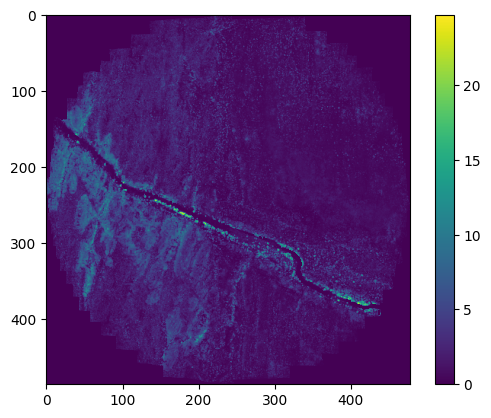

In [216]:
print((tmp == out).all())
    
plt.imshow(out[0], vmin=0)
plt.colorbar()

## step 3 - crop image tiles per site
We will use this tif to crop the sentinel tile into a smaller one for running eval.

In [6]:
site_ids = Karingani_sites
#test_site_ids = ["KaringaniSite11DevNodeF","KaringaniSite12","KaringaniSite16"]

In [8]:
all_site_ids

['KaringaniMassingirDevNode',
 'KaringaniSite14',
 'KaringaniSite16',
 'KaringaniVultureSite01',
 'KaringaniSungoloDevNode',
 'KaringaniSite17',
 'KaringaniSite13',
 'KaringaniSite15',
 'KaringaniSite11DevNodeF',
 'KaringaniSite01',
 'KaringaniSite12',
 'KaringaniSite08',
 'KaringaniSouthSouthDevNode',
 'KaringaniSite06',
 'KaringaniSite05']

In [13]:
sentinel_dirs = ['none',
                 '/n/home10/erolf/tree_mapping/data/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704',
                 '/n/home10/erolf/tree_mapping/data/sentinel/S2B_MSIL2A_20230413T073619_R092_T36KUU_20230413T131907'
                ]

s2_tiles_per_site = {'KaringaniMassingirDevNode':2,
 'KaringaniSite14':2,
 'KaringaniSite16':2,
 'KaringaniVultureSite01':1,
 'KaringaniSungoloDevNode':2,
 'KaringaniSite17':2,
 'KaringaniSite13':1,
 'KaringaniSite15':1,
 'KaringaniSite11DevNodeF':1,
 'KaringaniSite01':2,
 'KaringaniSite12':1,
 'KaringaniSite08':2,
 'KaringaniSouthSouthDevNode':1,
 'KaringaniSite06':2,
 'KaringaniSite05':2
                    }

In [38]:
for site_id in all_site_ids:
    sentinel_dir = sentinel_dirs[s2_tiles_per_site[site_id]]
    
    for s2_fn in list(os.listdir(sentinel_dir)):
        if not s2_fn.endswith('.tif'): continue
        input_fn = os.path.join(sentinel_dir, s2_fn)
    
        target_fn = f'/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs/{site_id}_CHM_1m_merged.tif'
        chunked_sentinel_dir = '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site'
        if not os.path.exists(chunked_sentinel_dir): os.mkdir(chunked_sentinel_dir)
        if not os.path.exists(f"{chunked_sentinel_dir}/{site_id}"): os.mkdir(f"{chunked_sentinel_dir}/{site_id}")
        output_fn = f"{chunked_sentinel_dir}/{site_id}/{s2_fn}"

        utils.crop_input_to_target_tif(input_fn, 
                                        output_fn, 
                                        target_fn, 
                                        buffer = 200,
                                    #    match_res=True,
                                        verbose=True)

['gdalwarp', '-overwrite', '-ot', 'Float32', '-t_srs', 'EPSG:32736', '-r', 'average', '-of', 'GTiff', '-te', '390213.0', '7349296.0', '397004.0', '7352396.0', '-co', 'COMPRESS=LZW', '-co', 'BIGTIFF=YES', '-dstnodata', '-9999', '/n/home10/erolf/tree_mapping/data/sentinel/S2B_MSIL2A_20230413T073619_R092_T36KUU_20230413T131907/T36KUU_20230413T073619_B08_10m.tif', '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniMassingirDevNode/T36KUU_20230413T073619_B08_10m.tif']
Creating output file that is 679P x 310L.
Processing /n/home10/erolf/tree_mapping/data/sentinel/S2B_MSIL2A_20230413T073619_R092_T36KUU_20230413T131907/T36KUU_20230413T073619_B08_10m.tif [1/1] : 0Using internal nodata values (e.g. 0) for image /n/home10/erolf/tree_mapping/data/sentinel/S2B_MSIL2A_20230413T073619_R092_T36KUU_20230413T131907/T36KUU_20230413T073619_B08_10m.tif.
...10...20...30...40...50...60...70...80...90...100 - done.
saved in /n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniMassingi

In [32]:
check_fp = '/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/KaringaniSite11DevNodeF/T36KVU_20230418T073611_TCI_10m.tif'

with rasterio.open(check_fp) as f:
    data = f.read()

## step 4 - do the same thing for DEM
We will use the croped DEM tiles into a smaller one for running eval with DEM.

In [33]:
# assumes you've already downloaded and merged the ASTER files from https://urs.earthdata.nasa.gov
dem_dir = '/n/home10/erolf/tree_mapping/data/dem/merged'
reload(utils)

<module 'utils' from '/n/home10/erolf/tree_mapping/process_data/../utils.py'>

In [34]:
site_id = 'KaringaniSite11DevNodeF'

[x for x in os.listdir(f'/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/{site_id}') if 'B04_10m.tif' in x]

['T36KVU_20230418T073611_B04_10m.tif']

In [44]:
for site_id in all_site_ids:
    
    for dem_fn in list(os.listdir(dem_dir)):
        if not dem_fn.endswith('.tif'): continue
        input_fn = os.path.join(dem_dir, dem_fn)
    
        # old way
        target_fn = f'/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs_10/{site_id}/{site_id}_CHM_10m_merged.tif'
        # merge to the already buffered images
        # buffer_relative_to_buffered_s2 = 0
        # s2_by_site_dir = f'/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/{site_id}'
        # example_s2_fn_this_site = [x for x in os.listdir(s2_by_site_dir) if 'B04_10m.tif' in x][0]
        # target_fn = os.path.join(s2_by_site_dir, example_s2_fn_this_site)
        
        chunked_dem_dir = '/n/home10/erolf/tree_mapping/data/int/dem_by_site'
        if not os.path.exists(chunked_dem_dir): os.mkdir(chunked_dem_dir)
        if not os.path.exists(f"{chunked_dem_dir}/{site_id}"): os.mkdir(f"{chunked_dem_dir}/{site_id}")
        output_fn = f"{chunked_dem_dir}/{site_id}/{dem_fn}"

        utils.crop_input_to_target_tif(input_fn, 
                                        output_fn, 
                                        target_fn, 
                                        buffer = buffer_relative_to_buffered_s2,
                                        match_res=True,
                                        verbose=True)

['gdalwarp', '-overwrite', '-ot', 'Float32', '-t_srs', 'EPSG:32736', '-r', 'average', '-of', 'GTiff', '-tr', '10.0', '10.0', '-te', '390413.0', '7349496.0', '396803.0', '7352196.0', '-co', 'COMPRESS=LZW', '-co', 'BIGTIFF=YES', '-dstnodata', '-9999', '/n/home10/erolf/tree_mapping/data/dem/merged/AST_merged.tif', '/n/home10/erolf/tree_mapping/data/int/dem_by_site/KaringaniMassingirDevNode/AST_merged.tif']
Creating output file that is 639P x 270L.
Processing /n/home10/erolf/tree_mapping/data/dem/merged/AST_merged.tif [1/1] : 0...10...20...30...40...50...60...70...80...90...100 - done.
saved in /n/home10/erolf/tree_mapping/data/int/dem_by_site/KaringaniMassingirDevNode/AST_merged.tif
['gdalwarp', '-overwrite', '-ot', 'Float32', '-t_srs', 'EPSG:32736', '-r', 'average', '-of', 'GTiff', '-tr', '10.0', '10.0', '-te', '401306.0', '7298008.0', '406096.0', '7302918.0', '-co', 'COMPRESS=LZW', '-co', 'BIGTIFF=YES', '-dstnodata', '-9999', '/n/home10/erolf/tree_mapping/data/dem/merged/AST_merged.tif'

img shape:  (1, 555, 572)
dem shape:  (1, 515, 532)
chm shape:  (1, 515, 532)


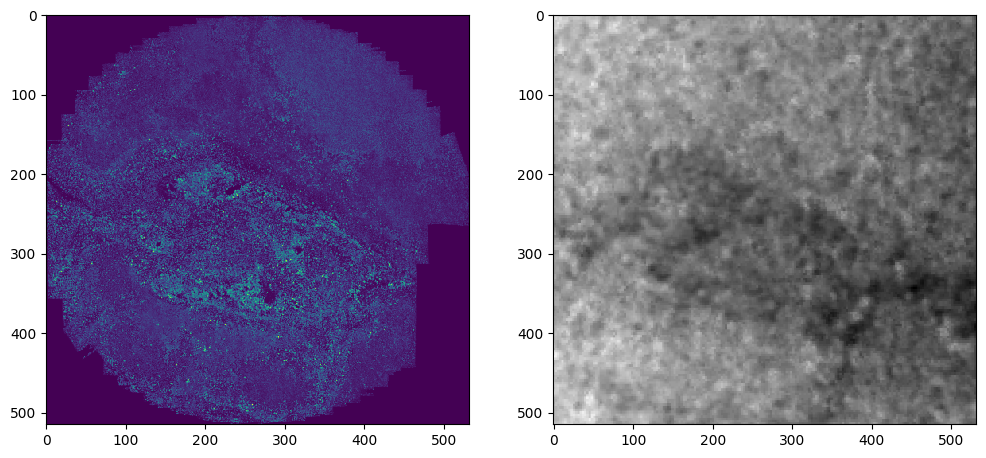

In [6]:
site_to_check = 'KaringaniSite11DevNodeF'

output_fn = f'/n/home10/erolf/tree_mapping/data/int/dem_by_site/{site_to_check}/AST_merged.tif'

# check the data
with rasterio.open(f'/n/home10/erolf/tree_mapping/data/int/sentinel_by_site/{site_to_check}/T36KVU_20230418T073611_B04_10m.tif') as f:
    i = f.read()

with rasterio.open(output_fn) as f:
    d = f.read()
    
with rasterio.open(f'/n/home10/erolf/tree_mapping/data/lidar/Karingani_merged_crs_10/{site_to_check}/{site_to_check}_CHM_10m_merged.tif') as f:
    t = f.read()
    
print('img shape: ', i.shape)
print('dem shape: ', d.shape)
print('chm shape: ', t.shape)

fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(t[0], vmin=0,vmax=14,interpolation="none",)
a = ax[1].imshow(d[0],interpolation="none",cmap='gray')